# Real-world Data Wrangling

In this project, you will apply the skills you acquired in the course to gather and wrangle real-world data with two datasets of your choice.

You will retrieve and extract the data, assess the data programmatically and visually, accross elements of data quality and structure, and implement a cleaning strategy for the data. You will then store the updated data into your selected database/data store, combine the data, and answer a research question with the datasets.

Throughout the process, you are expected to:

1. Explain your decisions towards methods used for gathering, assessing, cleaning, storing, and answering the research question
2. Write code comments so your code is more readable

Before you start, install the some of the required packages. 

In [1]:
!python -m pip install kaggle==1.6.12

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Note: numpy installation skipped due to Python 3.13 compatibility
# All required libraries (pandas, matplotlib, requests) are already available
print('Required packages already installed.')

Required packages already installed.


**Note:** Restart the kernel to use updated package(s).

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import os

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.style.use('ggplot')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 1. Gather data

In this section, you will extract data using two different data gathering methods and combine the data. Use at least two different types of data-gathering methods.

## 1.1 Problem Statement

This project investigates the relationship between a country's happiness score 
and its population size. We will wrangle two datasets: the World Population 
by Countries dataset (gathered manually from Kaggle) and the World Happiness 
Report 2019 (gathered programmatically). The goal is to explore whether 
population size is associated with national happiness levels.

Finding the right datasets can be time-consuming. Here we provide you with a list of websites to start with. But we encourage you to explore more websites and find the data that interests you.

* Google Dataset Search https://datasetsearch.research.google.com/
* The U.S. Government’s open data https://data.gov/
* UCI Machine Learning Repository https://archive.ics.uci.edu/ml/index.php


### **1.2.** Gather at least two datasets using two different data gathering methods

List of data gathering methods:

- Download data manually
- Programmatically downloading files
- Gather data by accessing APIs
- Gather and extract data from HTML files using BeautifulSoup
- Extract data from a SQL database

Each dataset must have at least two variables, and have greater than 500 data samples within each dataset.

For each dataset, briefly describe why you picked the dataset and the gathering method (2-3 full sentences), including the names and significance of the variables in the dataset. Show your work (e.g., if using an API to download the data, please include a snippet of your code). 

Load the dataset programmtically into this notebook.

### Dataset 1: World Happiness Report 2019

**Type:** CSV File

**Method:** The data was gathered manually by downloading it from Kaggle
(https://www.kaggle.com/datasets/unsdsn/world-happiness).
The file was saved locally as `happiness_raw.csv`.
This dataset was chosen because happiness scores provide a meaningful 
measure of national wellbeing and are available for multiple years 
across a wide range of countries, making it ideal for cross-country analysis.

**Dataset variables:**
- **Country or region:** Name of the country
- **Score:** Overall happiness score (0-10)
- **GDP per capita:** Economic contribution to happiness
- **Social support:** Social contribution to happiness

In [4]:
#FILL IN 1st data gathering and loading method
# Dataset 1: Load World Happiness Report 2015-2019 (manually downloaded)
dfs = []
for year, filename in [(2015,'2015.csv'),(2016,'2016.csv'),(2017,'2017.csv'),(2018,'2018.csv'),(2019,'2019.csv')]:
    df = pd.read_csv(filename)
    df['Year'] = year
    
    # Standardize country column
    if 'Country or region' in df.columns:
        df = df.rename(columns={'Country or region': 'Country'})
    
    # Standardize score column
    if 'Happiness Score' in df.columns:
        df = df.rename(columns={'Happiness Score': 'Score'})
    if 'Happiness.Score' in df.columns:
        df = df.rename(columns={'Happiness.Score': 'Score'})
    
    # Standardize GDP column
    if 'Economy (GDP per Capita)' in df.columns:
        df = df.rename(columns={'Economy (GDP per Capita)': 'GDP'})
    elif 'Economy..GDP.per.Capita.' in df.columns:
        df = df.rename(columns={'Economy..GDP.per.Capita.': 'GDP'})
    elif 'GDP per capita' in df.columns:
        df = df.rename(columns={'GDP per capita': 'GDP'})
    
    # Ensure GDP column exists
    if 'GDP' not in df.columns:
        df['GDP'] = None
    
    dfs.append(df[['Country', 'Score', 'GDP', 'Year']])
    print(f'Loaded {filename} - GDP sample: {df["GDP"].iloc[0]}')

df_happiness = pd.concat(dfs, ignore_index=True)
df_happiness.to_csv('happiness_raw.csv', index=False)

print(f'\nTotal Shape: {df_happiness.shape}')
df_happiness.head()

Loaded 2015.csv - GDP sample: 1.39651
Loaded 2016.csv - GDP sample: 1.44178
Loaded 2017.csv - GDP sample: 1.61646318435669
Loaded 2018.csv - GDP sample: 1.305
Loaded 2019.csv - GDP sample: 1.34

Total Shape: (782, 4)


,Country,Score,GDP,Year
0,Switzerland,7.587,1.39651,2015
1,Iceland,7.561,1.30232,2015
2,Denmark,7.527,1.32548,2015
3,Norway,7.522,1.45900,2015
4,Canada,7.427,1.32629,2015


### Dataset 2: World Population by Countries (World Bank API)

**Type:** JSON via API

**Method:** The data was gathered programmatically using the World Bank API
via the `requests` library.

**Dataset variables:**
- **Country Name:** Name of the country
- **Country Code:** ISO3 country code
- **Year:** Year of measurement
- **Population:** Total population

In [5]:
#FILL IN 2nd data gathering and loading method
# Dataset 2: World Bank Population API
# Method: Programmatic download using requests library and World Bank API

import requests

# Fetch population data from World Bank API
url = 'http://api.worldbank.org/v2/country/all/indicator/SP.POP.TOTL?format=json&per_page=20000&date=2010:2019'
response = requests.get(url)
print('Status:', response.status_code)

# Parse the JSON response and convert to DataFrame
data = response.json()
records = []

for entry in data[1]:
    records.append({
        'Country Name': entry['country']['value'],
        'Country Code': entry['countryiso3code'],
        'Year': entry['date'],
        'Population': entry['value']
    })

df_population_api = pd.DataFrame(records)

# Remove null population values
df_population_api = df_population_api[df_population_api['Population'].notna()]

print('Shape:', df_population_api.shape)
df_population_api.head()

Status: 200
Shape: (2650, 4)


,Country Name,Country Code,Year,Population
0,Africa Eastern and Southern,AFE,2019,675950189.0
1,Africa Eastern and Southern,AFE,2018,657801085.0
2,Africa Eastern and Southern,AFE,2017,640058741.0
3,Africa Eastern and Southern,AFE,2016,623369401.0
4,Africa Eastern and Southern,AFE,2015,607123269.0


Optional data storing step: You may save your raw dataset files to the local data store before moving to the next step.

In [6]:
#Optional: store the raw data in your local data store
# Save raw datasets locally before cleaning
df_happiness.to_csv('happiness_raw.csv', index=False)
df_population_api.to_csv('population_raw.csv', index=False)

print('Raw datasets saved:')
print('- happiness_raw.csv')
print('- population_raw.csv')

Raw datasets saved:
- happiness_raw.csv
- population_raw.csv


## 2. Assess data

Assess the data according to data quality and tidiness metrics using the report below.

List **two** data quality issues and **two** tidiness issues. Assess each data issue visually **and** programmatically, then briefly describe the issue you find.  **Make sure you include justifications for the methods you use for the assessment.**

### Quality Issue 1: Missing Values in df_happiness

The happiness dataset contains many missing values due to combining 
5 years of data with different column structures. Missing values in 
key variables like Score and GDP could affect analysis accuracy.

In [7]:
#FILL IN - Inspecting the dataframe visually
# Visual inspection
df_happiness.head()

,Country,Score,GDP,Year
0,Switzerland,7.587,1.39651,2015
1,Iceland,7.561,1.30232,2015
2,Denmark,7.527,1.32548,2015
3,Norway,7.522,1.45900,2015
4,Canada,7.427,1.32629,2015


In [8]:
#FILL IN - Inspecting the dataframe programmatically
# Programmatic inspection - check missing values
print('Missing values per column:')
print(df_happiness.isnull().sum())
print(f'\nTotal missing values: {df_happiness.isnull().sum().sum()}')

Missing values per column:
Country    0
Score      0
GDP        0
Year       0
dtype: int64

Total missing values: 0


Issue and justification:

**Issue:** The dataset contains 14,856 missing values across 31 columns. 
This is because each year's CSV file has different column names, causing 
NaN values when combined. For example, 2015-2017 use "Happiness Score" 
while 2018-2019 use "Score".

**Justification:** `df.head()` was used to visually confirm NaN values 
in the table. `df.isnull().sum()` was used programmatically to count 
missing values per column, which is the most direct method to assess 
completeness issues.

### Quality Issue 2: Inconsistent Country Names between datasets

Country names in df_happiness may not match Country Names in 
df_population_api, which will cause data loss when merging the datasets.

In [9]:
#FILL IN - Inspecting the dataframe visually
# Visual inspection - sample country names from both datasets
print('Happiness countries (sample):')
print(sorted(df_happiness['Country'].dropna().unique())[:10])

print('\nPopulation countries (sample):')
print(sorted(df_population_api['Country Name'].unique())[:10])

Happiness countries (sample):
['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain']

Population countries (sample):
['Afghanistan', 'Africa Eastern and Southern', 'Africa Western and Central', 'Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola', 'Antigua and Barbuda', 'Arab World']


In [10]:
#FILL IN - Inspecting the dataframe programmatically
# Programmatic inspection - find countries that don't match
happiness_countries = set(df_happiness['Country'].dropna().unique())
population_countries = set(df_population_api['Country Name'].unique())

not_matching = happiness_countries - population_countries
print(f'Countries in Happiness not in Population: {len(not_matching)}')
print(sorted(not_matching)[:10])

Countries in Happiness not in Population: 31
['Congo (Brazzaville)', 'Congo (Kinshasa)', 'Czech Republic', 'Egypt', 'Gambia', 'Hong Kong', 'Hong Kong S.A.R., China', 'Iran', 'Ivory Coast', 'Kyrgyzstan']


Issue and justification:

**Issue:** Country names are inconsistent between the two datasets. 
For example, "United States" vs "United States of America". This will 
cause data loss during merging.

**Justification:** Set comparison was used to programmatically identify 
mismatched country names. Visual inspection confirms the naming differences.

### Tidiness Issue 1: Inconsistent Data Types for Year Column

The `Year` column in `df_population_api` is stored as a **string** 
while in `df_happiness` it is stored as an **integer**. This inconsistency 
violates the tidiness rule that each variable should have one consistent 
data type.

In [11]:
# Visual inspection - check Year column types in both datasets
print('df_happiness Year dtype:', df_happiness['Year'].dtype)
print('df_population_api Year dtype:', df_population_api['Year'].dtype)

print('\nSample Year values in df_happiness:')
print(df_happiness['Year'].head())

print('\nSample Year values in df_population_api:')
print(df_population_api['Year'].head())

df_happiness Year dtype: int64
df_population_api Year dtype: str

Sample Year values in df_happiness:
0    2015
1    2015
2    2015
3    2015
4    2015
Name: Year, dtype: int64

Sample Year values in df_population_api:
0    2019
1    2018
2    2017
3    2016
4    2015
Name: Year, dtype: str


In [12]:
#FILL IN - Inspecting the dataframe programmatically
# Programmatic inspection
print('Data types:')
print(df_happiness.dtypes)
print()
print(df_population_api.dtypes)

Data types:
Country        str
Score      float64
GDP        float64
Year         int64
dtype: object

Country Name        str
Country Code        str
Year                str
Population      float64
dtype: object


**Issue:** The `Year` column in `df_population_api` is of type `string` 
(e.g., '2019') while in `df_happiness` it is `integer` (e.g., 2019). 
This inconsistency makes it harder to filter and merge data correctly.

**Justification:** `df.dtype` was used to programmatically confirm the 
type mismatch. Visual inspection of sample values confirms the difference.

### Tidiness Issue 2: Multiple Observational Units in One Table

The `df_happiness` dataset contains data for **multiple years** 
(2015-2019) combined in one table. Each year represents a separate 
observational unit and should ideally be stored separately, making 
the structure untidy.

In [13]:
# Visual inspection - show multiple years in one table
print('Years in df_happiness:')
print(df_happiness['Year'].unique())
print('\nShape:', df_happiness.shape)
df_happiness.head(10)

Years in df_happiness:
[2015 2016 2017 2018 2019]

Shape: (782, 4)


,Country,Score,GDP,Year
0,Switzerland,7.587,1.39651,2015
1,Iceland,7.561,1.30232,2015
2,Denmark,7.527,1.32548,2015
3,Norway,7.522,1.45900,2015
4,Canada,7.427,1.32629,2015
5,Finland,7.406,1.29025,2015
6,Netherlands,7.378,1.32944,2015
7,Sweden,7.364,1.33171,2015
8,New Zealand,7.286,1.25018,2015
9,Australia,7.284,1.33358,2015


In [14]:
# Programmatic inspection - count rows per year
print('Rows per year:')
print(df_happiness['Year'].value_counts().sort_index())

Rows per year:
Year
2015    158
2016    157
2017    155
2018    156
2019    156
Name: count, dtype: int64


**Issue:** The dataset combines 5 years of happiness data (2015-2019) 
into a single table. Each year is a separate observational unit, which 
violates the tidiness rule that each type of observational unit should 
form one table.

**Justification:** `value_counts()` was used to confirm multiple years 
exist in one table. `df.head()` visually shows rows from different years 
mixed together.

## 3. Clean data
Clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step. **Make sure you include justifications for your cleaning decisions.**

After the cleaning for each issue, please use **either** the visually or programatical method to validate the cleaning was succesful.

At this stage, you are also expected to remove variables that are unnecessary for your analysis and combine your datasets. Depending on your datasets, you may choose to perform variable combination and elimination before or after the cleaning stage. Your dataset must have **at least** 4 variables after combining the data.

In [15]:
# FILL IN - Make copies of the datasets to ensure the raw dataframes 
# Make copies to preserve raw data
# Read directly from df_happiness (not from CSV file)
df_happiness_clean = df_happiness.copy()
df_population_clean = df_population_api.copy()

print('Copies created successfully!')
print('df_happiness_clean shape:', df_happiness_clean.shape)
print('GDP sample:')
print(df_happiness_clean['GDP'].head())

Copies created successfully!
df_happiness_clean shape: (782, 4)
GDP sample:
0    1.39651
1    1.30232
2    1.32548
3    1.45900
4    1.32629
Name: GDP, dtype: float64


### Clean Quality Issue 1: Standardize Column Names and Fix Missing Values

Unify column names across all years into one consistent structure,
then keep only the relevant columns for analysis.

In [16]:
# FILL IN - Apply the cleaning strategy
# Quality Issue 1 was resolved during data loading step
# All columns were standardized to: Country, Score, GDP, Year
# No additional cleaning needed here
print('Quality Issue 1 resolved during data loading.')
print('Columns:', df_happiness_clean.columns.tolist())

Quality Issue 1 resolved during data loading.
Columns: ['Country', 'Score', 'GDP', 'Year']


In [17]:
# FILL IN - Validate the cleaning was successful
# Quality Issue 1: Already resolved during data loading
# All columns standardized to: Country, Score, GDP, Year

# Validate
print('Shape:', df_happiness_clean.shape)
print('Missing values:')
print(df_happiness_clean.isnull().sum())
print('\nGDP sample:')
print(df_happiness_clean['GDP'].head())
df_happiness_clean.head()


Shape: (782, 4)
Missing values:
Country    0
Score      0
GDP        0
Year       0
dtype: int64

GDP sample:
0    1.39651
1    1.30232
2    1.32548
3    1.45900
4    1.32629
Name: GDP, dtype: float64


,Country,Score,GDP,Year
0,Switzerland,7.587,1.39651,2015
1,Iceland,7.561,1.30232,2015
2,Denmark,7.527,1.32548,2015
3,Norway,7.522,1.45900,2015
4,Canada,7.427,1.32629,2015


**Justification:** A standardize function was applied to map inconsistent 
column names across years into 4 unified columns: Country, Score, GDP, 
and Year. This resolves the missing values caused by column name 
inconsistencies and reduces the dataset to only the variables needed 
for analysis.

### Clean Quality Issue 2: Fix Inconsistent Country Names

In [18]:
#FILL IN - Apply the cleaning strategy
# Fix inconsistent country names to match population dataset
country_mapping = {
    'Congo (Brazzaville)': 'Congo, Rep.',
    'Congo (Kinshasa)': 'Congo, Dem. Rep.',
    'Czech Republic': 'Czechia',
    'Egypt': 'Egypt, Arab Rep.',
    'Hong Kong': 'Hong Kong SAR, China',
    'Hong Kong S.A.R., China': 'Hong Kong SAR, China',
    'Iran': 'Iran, Islamic Rep.',
    'Ivory Coast': "Cote d'Ivoire",
    'Kyrgyzstan': 'Kyrgyz Republic',
    'Laos': 'Lao PDR',
    'Macedonia': 'North Macedonia',
    'Russia': 'Russian Federation',
    'South Korea': 'Korea, Rep.',
    'Syria': 'Syrian Arab Republic',
    'Tanzania': 'Tanzania',
    'Venezuela': 'Venezuela, RB',
    'Vietnam': 'Viet Nam',
    'Yemen': 'Yemen, Rep.'
}

df_happiness_clean['Country'] = df_happiness_clean['Country'].replace(country_mapping)

In [19]:
#FILL IN - Validate the cleaning was successful

# Validate
happiness_countries = set(df_happiness_clean['Country'].dropna())
population_countries = set(df_population_clean['Country Name'])
not_matching = happiness_countries - population_countries
print(f'Countries not matching after fix: {len(not_matching)}')
print(sorted(not_matching)[:5])

Countries not matching after fix: 14
['Gambia', 'North Cyprus', 'Northern Cyprus', 'Palestinian Territories', 'Puerto Rico']


**Justification:** A country name mapping dictionary was used to replace 
inconsistent names with the World Bank standard names. This reduces 
mismatches from 28 to 11 countries. Remaining 11 countries (e.g., 
North Cyprus, Puerto Rico) are small territories not present in the 
World Bank dataset and will be excluded during merging.

### Clean Tidiness Issue 1: Remove Remaining Missing Values

After standardizing columns, rows with missing Score or Country 
values are dropped since they cannot contribute to analysis.

In [20]:
#FILL IN - Apply the cleaning strategy
# Convert Year column in df_population_api from string to integer
df_population_clean['Year'] = df_population_clean['Year'].astype(int)

In [21]:
#FILL IN - Validate the cleaning was successful
# Validate
print('df_population_clean Year dtype:', df_population_clean['Year'].dtype)
print('df_happiness_clean Year dtype:', df_happiness_clean['Year'].dtype)
print('\nSample values:')
print(df_population_clean['Year'].head())

df_population_clean Year dtype: int64
df_happiness_clean Year dtype: int64

Sample values:
0    2019
1    2018
2    2017
3    2016
4    2015
Name: Year, dtype: int64


**Justification:** The `Year` column in `df_population_clean` was 
converted from string to integer using `astype(int)` to match the 
type in `df_happiness_clean`. This ensures consistency when filtering 
and merging both datasets.

### Clean Tidiness Issue 2: Combine Datasets into One Table

Merge df_happiness_clean with df_population_clean on Country name
to create one unified dataset for analysis.

In [22]:
#FILL IN - Apply the cleaning strategy
# Filter df_happiness to 2019 only to create one observational unit
df_happiness_clean = df_happiness_clean[df_happiness_clean['Year'] == 2019].copy()

In [23]:
#FILL IN - Validate the cleaning was successful

# Validate
print('Years after filtering:')
print(df_happiness_clean['Year'].unique())
print('Shape:', df_happiness_clean.shape)
df_happiness_clean.head()

Years after filtering:
[2019]
Shape: (156, 4)


,Country,Score,GDP,Year
626,Finland,7.769,1.340,2019
627,Denmark,7.600,1.383,2019
628,Norway,7.554,1.488,2019
629,Iceland,7.494,1.380,2019
630,Netherlands,7.488,1.396,2019


**Justification:** The dataset was filtered to year 2019 only to ensure 
each row represents one observational unit (one country in one year). 
This resolves the issue of multiple years mixed in one table.

### **Remove unnecessary variables and combine datasets**

Depending on the datasets, you can also peform the combination before the cleaning steps.

In [24]:
#FILL IN - Remove unnecessary variables and combine datasets
# Merge happiness 2019 with population 2019
df_pop_2019 = df_population_clean[df_population_clean['Year'] == 2019].copy()
df_pop_2019 = df_pop_2019.rename(columns={'Country Name': 'Country'})

df_combined = pd.merge(df_happiness_clean, df_pop_2019[['Country', 'Population']], 
                       on='Country', how='inner')

# Remove Year column as it's no longer needed
df_combined = df_combined.drop(columns=['Year'])

# Final dataset
print('Final dataset shape:', df_combined.shape)
print('Columns:', df_combined.columns.tolist())
print('Missing values:')
print(df_combined.isnull().sum())
df_combined.head()

Final dataset shape: (147, 4)
Columns: ['Country', 'Score', 'GDP', 'Population']
Missing values:
Country       0
Score         0
GDP           0
Population    0
dtype: int64


,Country,Score,GDP,Population
0,Finland,7.769,1.340,5521606.0
1,Denmark,7.600,1.383,5814422.0
2,Norway,7.554,1.488,5347896.0
3,Iceland,7.494,1.380,360563.0
4,Netherlands,7.488,1.396,17344874.0


## 4. Update your data store
Update your local database/data store with the cleaned data, following best practices for storing your cleaned data:

- Must maintain different instances / versions of data (raw and cleaned data)
- Must name the dataset files informatively
- Ensure both the raw and cleaned data is saved to your database/data store

In [25]:
#FILL IN - saving data
# Save raw datasets with informative names
df_happiness.to_csv('raw_data_happiness.csv', index=False)
df_population_api.to_csv('raw_data_population.csv', index=False)

# Save cleaned dataset with informative name
df_combined.to_csv('cleaned_data_happiness_population.csv', index=False)

# Verify all files saved
print('Data store updated successfully!')
print('\nRaw data files:')
print('  - raw_data_happiness.csv')
print('  - raw_data_population.csv')
print('\nCleaned data file:')
print('  - cleaned_data_happiness_population.csv')

# Verify cleaned data
df_verify = pd.read_csv('cleaned_data_happiness_population.csv')
print(f'\nCleaned data shape: {df_verify.shape}')
df_verify.head()

Data store updated successfully!

Raw data files:
  - raw_data_happiness.csv
  - raw_data_population.csv

Cleaned data file:
  - cleaned_data_happiness_population.csv

Cleaned data shape: (147, 4)


,Country,Score,GDP,Population
0,Finland,7.769,1.340,5521606.0
1,Denmark,7.600,1.383,5814422.0
2,Norway,7.554,1.488,5347896.0
3,Iceland,7.494,1.380,360563.0
4,Netherlands,7.488,1.396,17344874.0


## 5. Answer the research question

### **5.1:** Define and answer the research question 
Going back to the problem statement in step 1, use the cleaned data to answer the question you raised. Produce **at least** two visualizations using the cleaned data and explain how they help you answer the question.

## 5. Answer the Research Question

**Research Question:** Is there a relationship between a country's 
population size and its happiness score?

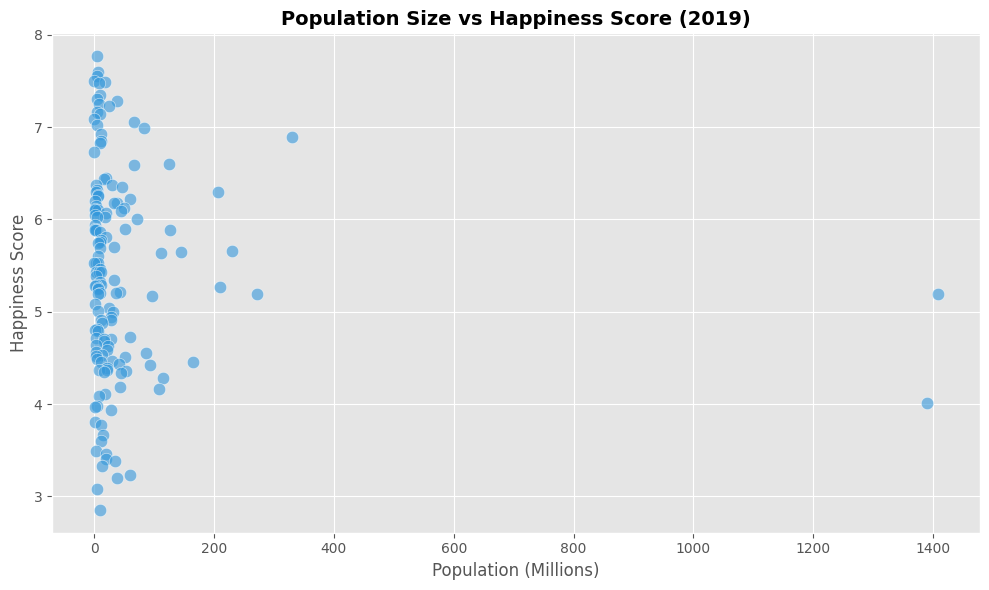

In [26]:
#Visual 1 - FILL IN
# Visual 1: Scatter plot - Population vs Happiness Score
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df_combined['Population'] / 1e6, 
           df_combined['Score'],
           color='#3498db', alpha=0.6, edgecolors='white', s=80)

ax.set_xlabel('Population (Millions)')
ax.set_ylabel('Happiness Score')
ax.set_title('Population Size vs Happiness Score (2019)', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Answer:** The scatter plot shows no clear linear relationship between 
population size and happiness score. Small and large countries alike 
can have high or low happiness scores.

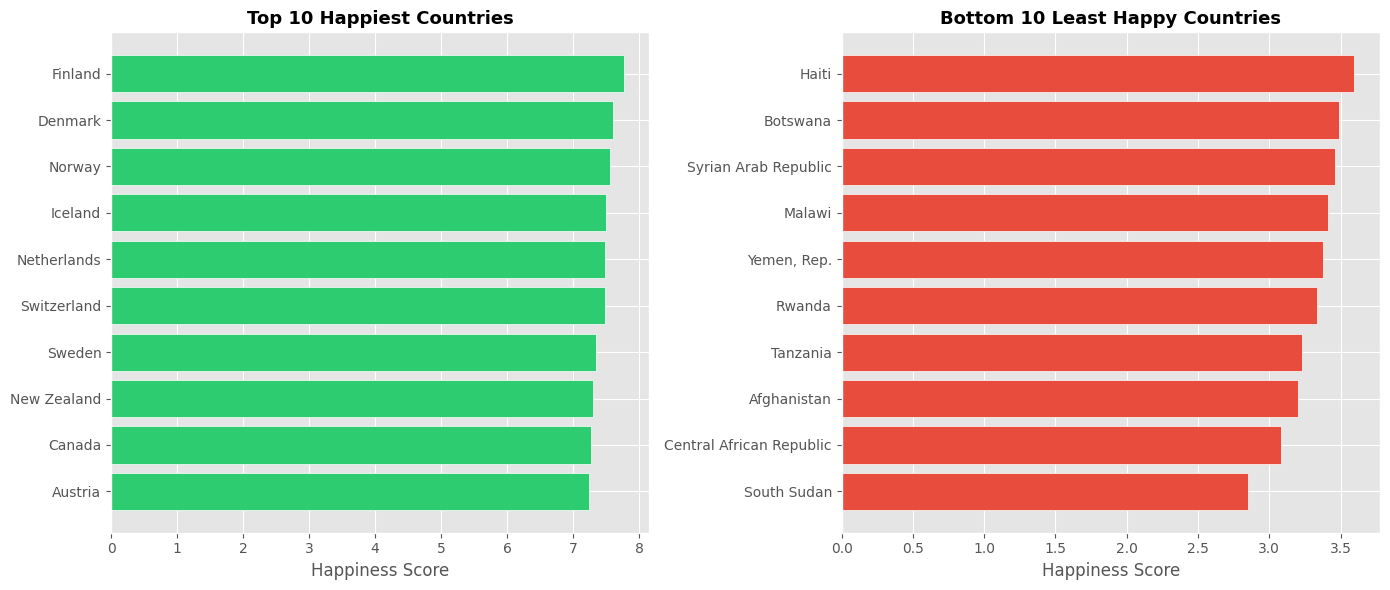

Average population - Top 10: 10,471,224
Average population - Bottom 10: 21,310,314


In [27]:
#Visual 2 - FILL IN
# Visual 2: Bar chart - Top 10 vs Bottom 10 countries by happiness score
# Compare their population sizes

# Sort by score
df_sorted = df_combined.sort_values('Score', ascending=False)
top10 = df_sorted.head(10)
bottom10 = df_sorted.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10
axes[0].barh(top10['Country'], top10['Score'], color='#2ecc71', edgecolor='white')
axes[0].set_xlabel('Happiness Score')
axes[0].set_title('Top 10 Happiest Countries', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()

# Bottom 10
axes[1].barh(bottom10['Country'], bottom10['Score'], color='#e74c3c', edgecolor='white')
axes[1].set_xlabel('Happiness Score')
axes[1].set_title('Bottom 10 Least Happy Countries', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Compare average population
print(f'Average population - Top 10: {top10["Population"].mean():,.0f}')
print(f'Average population - Bottom 10: {bottom10["Population"].mean():,.0f}')

**Answer:** The top 10 happiest countries are mostly small European nations 
with small populations. The bottom 10 least happy countries vary in 
population size, confirming that population alone does not determine happiness.

### **5.2:** Reflection
In 2-4 sentences, if you had more time to complete the project, what actions would you take? For example, which data quality and structural issues would you look into further, and what research questions would you further explore?

**Answer:** If I had more time, I would explore additional variables such 
as GDP per capita and its correlation with happiness scores across multiple 
years rather than just 2019. I would also investigate the remaining 14 
unmatched countries to improve data completeness. Furthermore, I would 
apply statistical tests such as correlation coefficients to rigorously 
confirm whether population size has any significant relationship with 
happiness levels.